# Initial Imports and Constants

In [413]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math

In [414]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [415]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [416]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [417]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)


SearchResult containing 28 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 18 TESS Sector 73 2023   SPOC     120   269701147      0.0
 19 TESS Sector 75 2024   SPOC     120   269701147      0.0
 20 TESS Sector 76 2024   SPOC     120   269701147      0

In [418]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [419]:
### mask transits out before normalizing and removing outliers 
if mask_transits == True:
    ### mask transit times before flattening
    transit_times1 = [1715.3554138170766, 1733.1177052058397, 1741.9966790217254, 1759.7594863949794, 
                      1786.3993327524447, 1795.282812306814, 1804.1612053097028, 1813.0412851350552, 
                      1821.916679839008, 1830.8024060885173, 1839.679488809774, 1875.2038254524273, 
                      1892.9635321154021, 1901.8429421464, 1910.7243706894353, 1919.6014862983075, 
                      1964.0017234662705, 1972.8840175983191, 1981.772340191726, 1990.6462804508126, 
                      1999.5263077432971, 2008.4039596061257, 2425.7823602178973, 2434.665753703352, 
                      2443.5401199500425, 2612.2659301853823, 2621.1526606995917, 2630.026049936838, 
                      2647.78925837366, 2656.6690060789174, 2701.071024209959, 2718.832941229813, 
                      2727.7122910625912, 2736.5929927033103, 2798.753562798274, 2807.631606144323, 
                      2816.5145749951785, 2825.39724742401, 2834.27756074832, 2843.1571257919904, 
                      2852.0360595551683, 2914.1986657751954, 2923.0777268631805, 2931.957374276408, 
                      2940.8424075548396, 2949.727777904308, 2958.6047945664563, 3296.0523006529143, 
                      3340.452383395677, 3349.334429186155, 3358.2137670764673, 3367.0975293098636, 
                      3375.976014607118, 3384.85776019437, 3393.7372044616886, 3402.618385542137, 
                      3420.3760644594613, 3438.1395925469596, 3447.0181886727523, 3455.899535804247, 
                      3464.780911184889, 3473.6635658428168, 3535.82385258115, 3544.7004968447172, 
                      3553.5818340529354, 3562.46315152199, 3571.344736350389, 3580.223329356114, 
                      3615.746065263641, 3660.1433746495345]
    transit_times2 = [1726.0523053710463, 1754.631708295026, 1783.207808278371, 1811.7977072487533, 
                      1840.3790498376009, 1897.5383037442973, 1926.120784518578, 2440.5413950174407, 
                      2612.030879088145, 2697.776164728058, 2726.3549902906316, 2812.0987921984606, 
                      2840.6709928374466, 2926.427219926762, 3297.975332441588, 3355.126550196479, 
                      3383.7037141332803, 3440.8760685135303, 3555.1920284121047, 3583.7717959299225, 
                      3640.929070419659]
    transit_times3 = [1743.5549515650207, 1781.9037349904463, 1820.2652060175265, 1896.9603377736353, 
                      1973.6650674805467, 2433.9166506358474, 2664.0225435336465, 2702.352538776791, 
                      2740.7147499868743, 2817.4104839147385, 2932.462260903496, 3354.3003236080353, 
                      3392.6619207076765, 3546.073128223445, 3622.766267812653, 3661.127690895217]
    T14_1= 2.939 * 0.0416667 
    T14_2= 4.162 * 0.0416667 
    T14_3= 5.36 * 0.0416667
    
    masked_lc = lc_collection.stitch()

    times = masked_lc.time.value

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_times1:
        mask |= (times > (transit_time - T14_1/2)) & (times < (transit_time + T14_1/2))

    for transit_time in transit_times2:
        mask |= (times > (transit_time - T14_2/2)) & (times < (transit_time + T14_2/2))

    for transit_time in transit_times3:
        mask |= (times > (transit_time - T14_3/2)) & (times < (transit_time + T14_3/2))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=1901, mask=mask).remove_outliers()
    combined_lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    combined_lc = lc.flatten(window_length=1901).remove_outliers()

# combined_lc.plot()
# plt.show()

In [420]:
# clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [421]:
# # Normalize, flatten, and remove outliers
# processed_lcs = [
#     lc.normalize().flatten(window_length=1901).remove_outliers(sigma=5)
#     for lc in clean_lcs
# ]

In [422]:
# # Stitch into one combined light curve
# combined_lc = processed_lcs[0]
# for lc in processed_lcs[1:]:
#     combined_lc = combined_lc.append(lc)



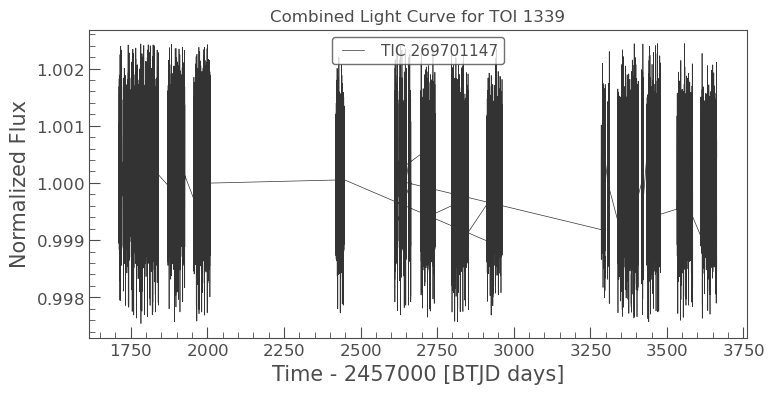

In [423]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [424]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82380309 3662.82519195
 3662.82658081]
[1.0004954  0.99923556 1.00039801 ... 0.99994367 1.00031003 1.00043258]


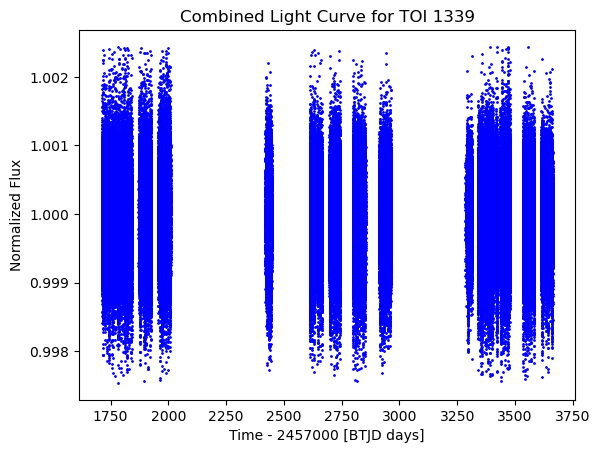

In [425]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 147250 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


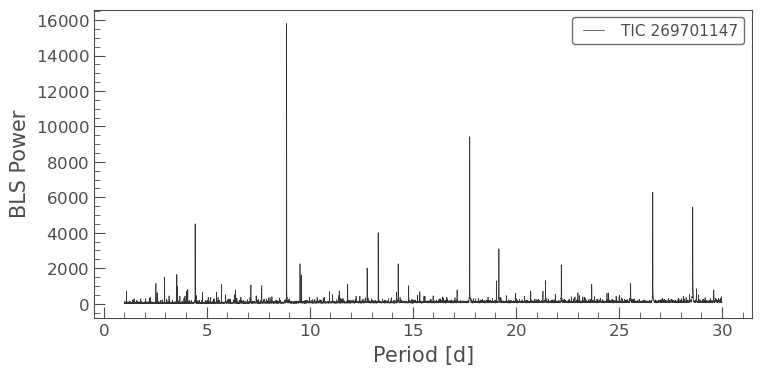

In [426]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 30, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [427]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 8.88009 days
Best candidate t0: 1715.38577 days
Best candidate dur: 0.10000 days


In [428]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*2.5)

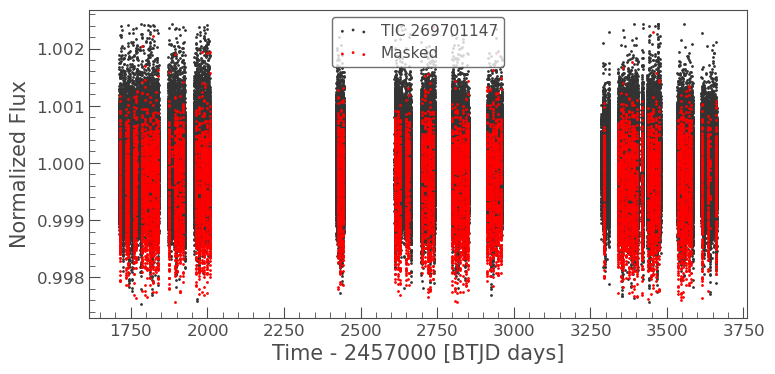

In [429]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [430]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


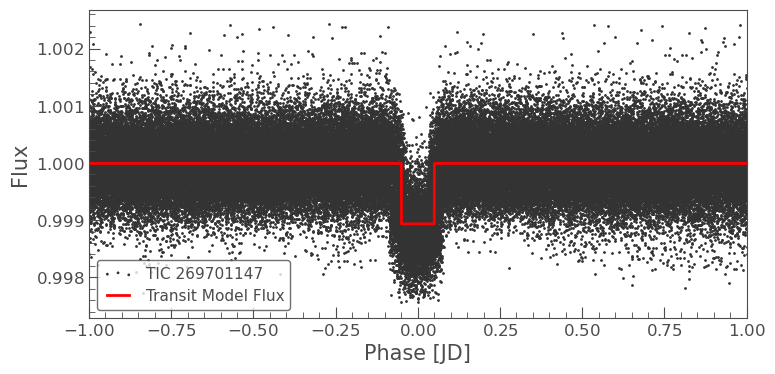

In [431]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


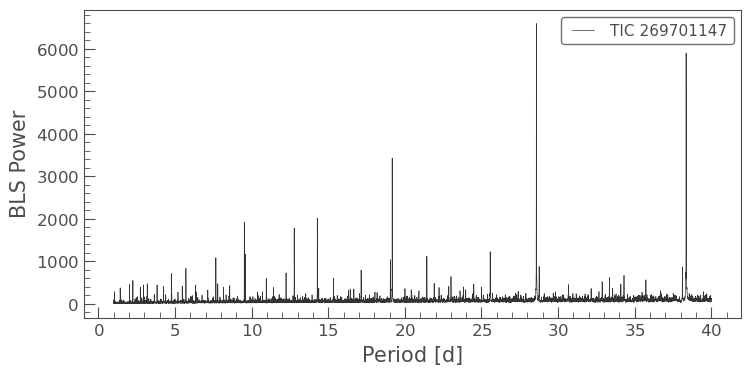

In [432]:
period = np.linspace(1, 40, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [433]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 28.57966 days
Best candidate t0 2: 1726.07077 days


In [434]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [435]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*2.5)

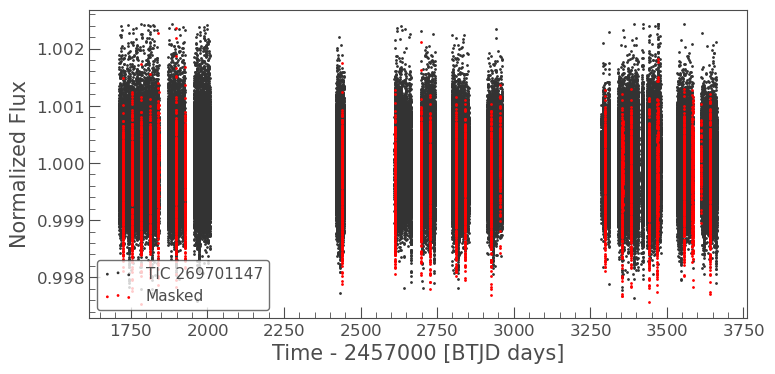

In [436]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [437]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

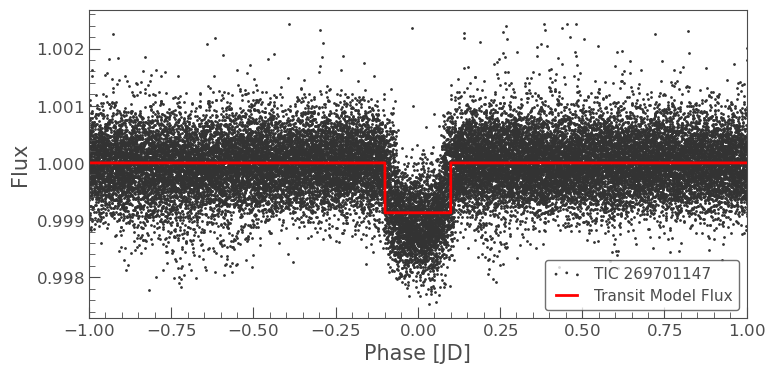

In [438]:
ax = combined_lc.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


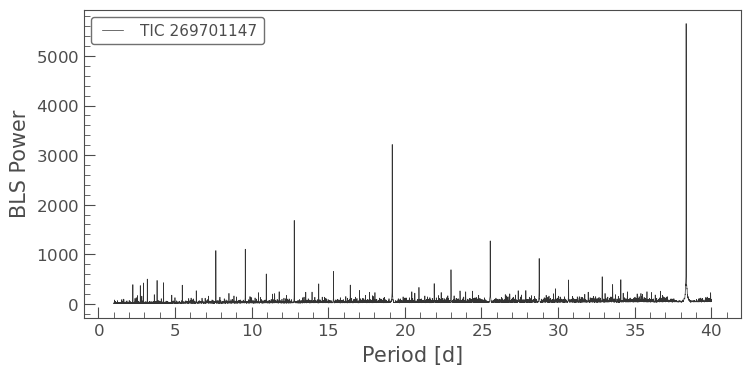

In [439]:
period = np.linspace(1, 40, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [440]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 38.35014 days
Best candidate t0 3: 1743.60077 days


In [441]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*2.5)

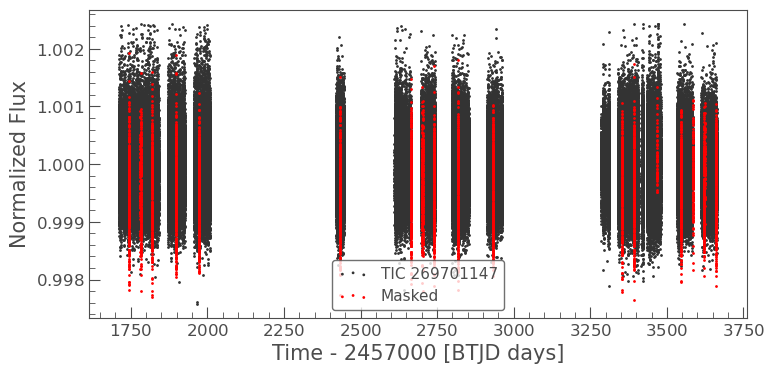

In [442]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [443]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

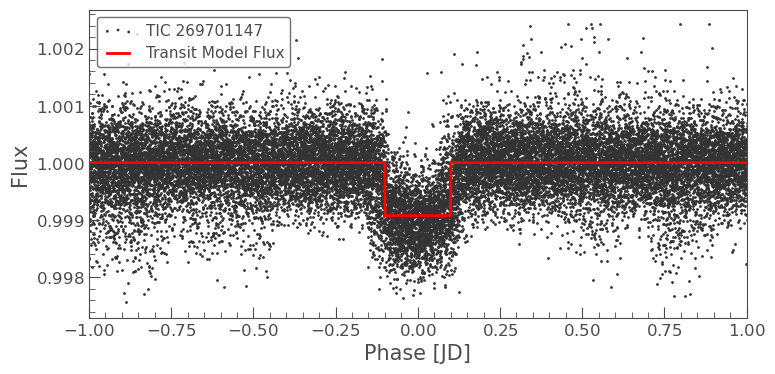

In [444]:
ax = combined_lc.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## transit models 

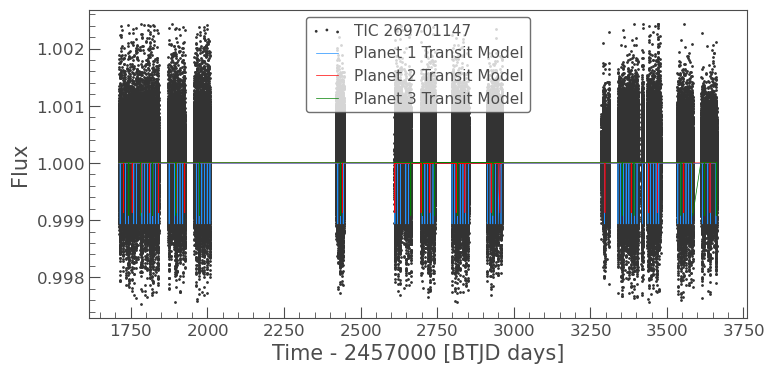

In [445]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## find transit times based on models

In [446]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = np.sort(planet_1_model.time.value[peaks_1])
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1715.38527704 1733.14523276 1742.02587491 1759.78567928 1768.66761612
 1786.4258593  1795.30633585 1804.18539619 1813.06580968 1821.94620939
 1830.82659697 1839.70835103 1875.22701533 1892.98638832 1901.86679936
 1910.7472269  1919.62767918 1964.02758268 1972.90820848 1981.78885672
 1990.66813566 1999.54883028 2008.42815048 2425.79153607 2434.67226022
 2443.55296614 2612.27377137 2621.1541622  2630.03455845 2647.79543122
 2656.67451159 2701.07452772 2709.95377835 2718.83444273 2727.71512723
 2736.59721779 2798.75539797 2807.63611065 2816.51540916 2825.39607959
 2834.27672658 2843.15595796 2852.03656006 2914.19716427 2923.07756003
 2931.95654011 2940.83690204 2949.71726739 2958.59762072 3296.0411228
 3340.44153921 3349.32191666 3358.20092089 3367.08134645 3375.96316842
 3384.84224467 3393.71996638 3402.60186901 3420.36255094 3438.12240868
 3447.00167214 3455.88235194 3464.76305999 3473.64237797 3535.80333204
 3544.68264565 3553.56331552 3562.44396

In [447]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = np.sort(planet_2_model.time.value[peaks_2])
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1726.07015657 1754.64955949 1783.23005136 1811.8088851  1840.38750416
 1897.54742539 1926.1276247  2440.56124822 2612.03905394 2697.77866723
 2726.35816013 2812.0972907  2840.67816668 2926.41637574 2955.06852961
 3297.9508079  3355.110701   3383.69086794 3440.8502093  3469.42980131
 3555.16750387 3583.74827239 3640.90754888]


In [448]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
transit_times_3 = np.sort(planet_3_model.time.value[peaks_3])
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)

Planet 3 transit dip times and depths:
[1743.59949615 1781.95228358 1820.30040791 1897.00021101 1973.70127038
 2433.90280344 2664.005026   2702.35370661 2740.70423947 2817.40431107
 2932.45375239 3354.30516178 3392.65608153 3546.05627803 3584.34133025
 3622.75642463 3661.10717036]


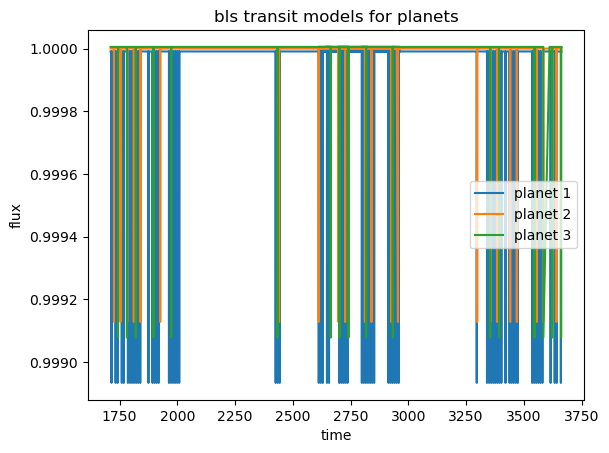

In [449]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1700,1800)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [450]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [451]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [452]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        # ### fit parabola to the chisq
        # p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        # ### Extract the coefficients   y = ax^2 + bx + c
        # a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        # ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        # tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        # ### Calculate the minimum chi-squared value
        # chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        # tc_chi_parabola[j] = tc_best_fit
    
        # ### Calculate the parabola best fit 
        # p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        # ### calculate ttv from parabola fit 
        # ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        # err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # Find the intersection using root_scalar
        intersections = []
        for k in range(len(tc1) - 1):
            if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
                sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
                if sol.converged:
                    intersections.append((sol.root - min_chi_time))
        errors.append(intersections)

        # errors = np.array(errors)

        # ### avg the errors
        # sig = np.sqrt(errors[0]**2 + errors[1]**2)
        # err_tc_chi.append(sig)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv, errors

In [453]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [454]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [455]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

0.44108956006688715
0.11027239001672175


## Planet 1

In [456]:
### Planet params 
# planet b
per_1=  8.8803232 #8.8803256
rp_1= 0.0333265970068500 #0.03319
b_1=  0.522936735232103 #0.610
T14_1= 3.06623299086887 * 0.0416667  #2.939 * 0.0416667  # convert to days from hours 


In [457]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [458]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []
err_tc_chi = []

In [459]:
tc_chi_1, ttv_1, tc_err1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [460]:
print(tc_chi_1)
# print(tc_err1)
# print(len(tc_chi_1))
# print(len(tc_err1))

[1715.35474648 1733.11536953 1741.99634535 1759.75881906 1768.63641823
 1786.39866542 1795.28314597 1804.15920331 1813.03928313 1821.91801451
 1830.80173875 1839.68048981 1875.20148978 1892.96286478 1901.84327581
 1910.72236869 1919.6014863  1964.00372547 1972.8840176  1981.76466584
 1990.64461211 1999.52463941 2008.40529428 2425.78269389 2434.6627507
 2443.54245562 2612.26626385 2621.1506587  2630.02805194 2647.78959204
 2656.66967341 2701.07335988 2709.95261052 2718.8322739  2727.71095639
 2736.59237961 2798.75389647 2807.63460915 2816.51490866 2825.39624642
 2834.27822808 2843.15679212 2852.03605956 2914.19599644 2923.07772686
 2931.95704061 2940.84407589 2949.72110456 2958.60179156 3296.05129965
 3340.45405173 3349.33376185 3358.21410074 3367.09652831 3375.97634827
 3384.85575819 3393.73881858 3402.61705087 3420.37372879 3438.14059355
 3447.01918967 3455.89886847 3464.77991018 3473.66189751 3535.82218424
 3544.69949584 3553.58183405 3562.46348519 3571.34406902 3580.22232835
 3615.7

In [461]:
### after inspection of single transits
values_to_remove_1 = [1768.66578095, 2709.95160951, 3633.50724503, 3642.20057877844]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_1_cleaned = []
ttv_1_cleaned = []
tc_err_1_cleaned = []

for i in range(len(tc_chi_1)):
    if not any(math.isclose(tc_chi_1[i], val, abs_tol=tolerance) for val in values_to_remove_1):
        tc_chi_1_cleaned.append(tc_chi_1[i])
        ttv_1_cleaned.append(ttv_1[i])
        tc_err_1_cleaned.append(tc_err1[i])

# Overwrite the originals if needed
tc_chi_1 = tc_chi_1_cleaned
ttv_1 = ttv_1_cleaned
tc_err1 = tc_err_1_cleaned
print("Modified List (after removal):", tc_chi_1)
# print(tc_err1)


Modified List (after removal): [1715.354746482542, 1733.115369534969, 1741.996345354458, 1759.758819060445, 1786.3986654179103, 1795.2831459740814, 1804.1592033060992, 1813.0392831314516, 1821.9180145080772, 1830.8017387539828, 1839.6804898115759, 1875.2014897815563, 1892.9628647808674, 1901.843275813667, 1910.7223686858317, 1919.6014862983075, 1964.003725469874, 1972.8840175983191, 1981.7646658445788, 1990.644612114476, 1999.524639406961, 2008.4052942751948, 2425.7826938851645, 2434.6627506979466, 2443.542455620913, 2612.2662638526494, 2621.150658695988, 2630.0280519404414, 2647.789592040927, 2656.669673413452, 2701.07335988083, 2718.832273895279, 2727.7109563935223, 2736.5923796134493, 2798.753896465541, 2807.6346091497285, 2816.5149086624456, 2825.396246422208, 2834.2782280828546, 2843.1567921247233, 2852.0360595551683, 2914.195996437057, 2923.0777268631805, 2931.9570406091407, 2940.8440758911756, 2949.7211045589625, 2958.601791561051, 3296.0512996511125, 3340.4540517320133, 3349.33

In [462]:
# tc_err_1 = []
# for i in range(len(tc_err1)):
#     sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
#     tc_err_1.append(sig)

tc_err_1 = []
for i in range(len(tc_err1)):
    if len(tc_err1[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
        tc_err_1.append(sig)
    else:
        print(f"Unexpected format in tc_err1[{i}]: {tc_err1[i]}, {tc_chi_1[i]}")

# print(tc_err_1)

In [463]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

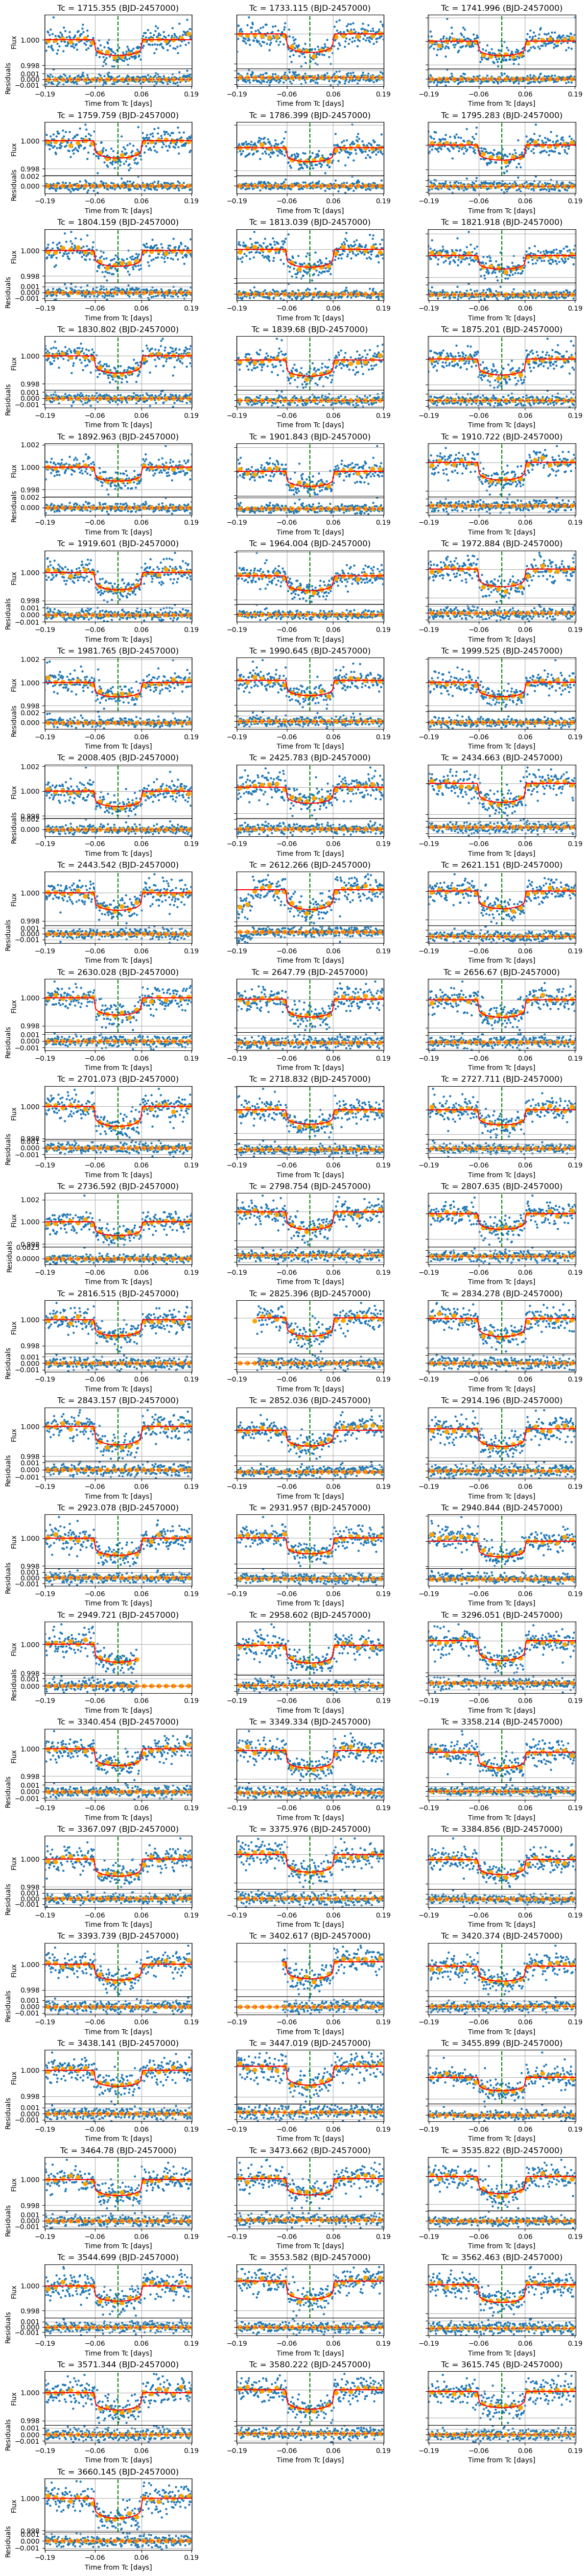

In [464]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

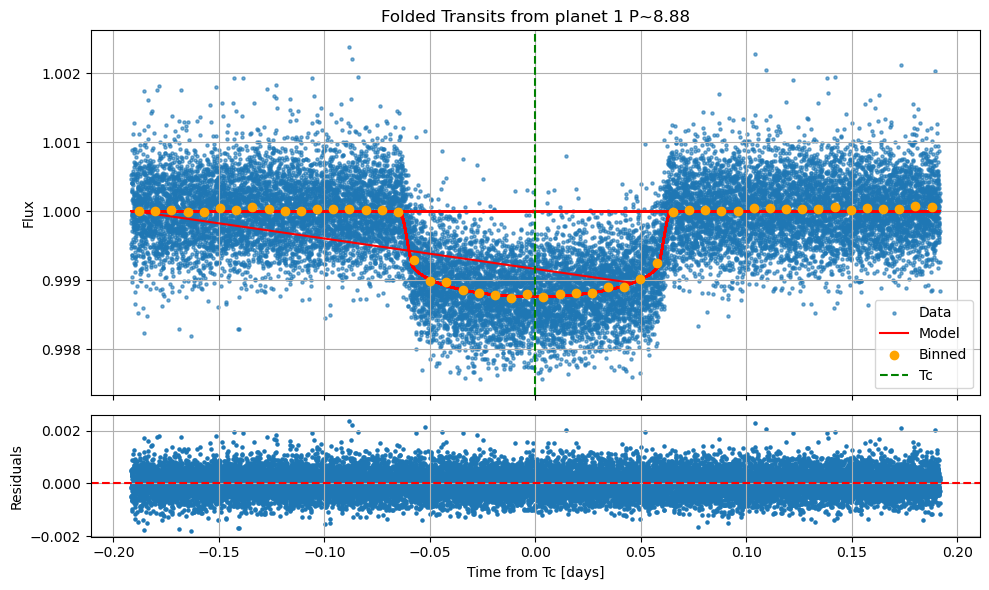

In [465]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [466]:
### Planet params (from barros et al 2022)
# planet b
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [467]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [468]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []
err_tc_chi = []

In [469]:
tc_chi_2, ttv_2, tc_err2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [470]:
print(tc_chi_2)

[1726.05430737 1754.63404397 1783.21153283 1811.79970925 1840.37532531
 1897.53558021 1926.11644684 2440.54640003 2612.02854342 2697.77182705
 2726.35198729 2812.09545553 2840.67232751 2926.42154758 2954.99095197
 3297.9726631  3355.1305542  3383.71038748 3440.87540118 3469.41662146
 3555.19503142 3583.7721296  3640.93307443]


In [471]:
### after inspection of single transits
values_to_remove_2 = [2954.9979589823915, 3469.42362847]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_2_cleaned = []
ttv_2_cleaned = []
tc_err_2_cleaned = []

for i in range(len(tc_chi_2)):
    if not any(math.isclose(tc_chi_2[i], val, abs_tol=tolerance) for val in values_to_remove_2):
        tc_chi_2_cleaned.append(tc_chi_2[i])
        ttv_2_cleaned.append(ttv_2[i])
        tc_err_2_cleaned.append(tc_err2[i])

# Overwrite the originals if needed
tc_chi_2 = tc_chi_2_cleaned
ttv_2 = ttv_2_cleaned
tc_err2 = tc_err_2_cleaned
print("Modified List (after removal):", tc_chi_2)


Modified List (after removal): [1726.0543073746499, 1754.634043965897, 1783.2115328271677, 1811.799709252357, 1840.375325305024, 1897.535580205685, 1926.1164468441034, 2440.5464000264496, 2612.028543417274, 2697.771827053584, 2726.351987285226, 2812.0954555257877, 2840.6723275065156, 2926.4215475832184, 3297.9726631034496, 3355.130554203686, 3383.7103874786258, 3440.8754011789956, 3555.19503141751, 3583.7721295971896, 3640.9330744268664]


In [472]:
# tc_err_2 = []
# for i in range(len(tc_err2)):
#     sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
#     tc_err_2.append(sig)

tc_err_2 = []
for i in range(len(tc_err2)):
    if len(tc_err2[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
        tc_err_2.append(sig)
    else:
        print(f"Unexpected format in tc_err2[{i}]: {tc_err2[i]}, {tc_chi_2[i]}")

print(tc_err_2)

[0.0018261459082440808, 0.0016975194571750953, 0.001941892605016842, 0.0019334560011131287, 0.0016351513804173645, 0.0021327954252379636, 0.001954113802138396, 0.002172370933625506, 0.00200479087259155, 0.0017786081068917805, 0.0015459523926204713, 0.001955360675833153, 0.0017960964222045745, 0.0017669218575431013, 0.002157404474588076, 0.00108432030763372, 0.001754653778278287, 0.001375672714534308, 0.0013256881445249953, 0.0021090264939909913, 0.0022331876682329345]


In [473]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

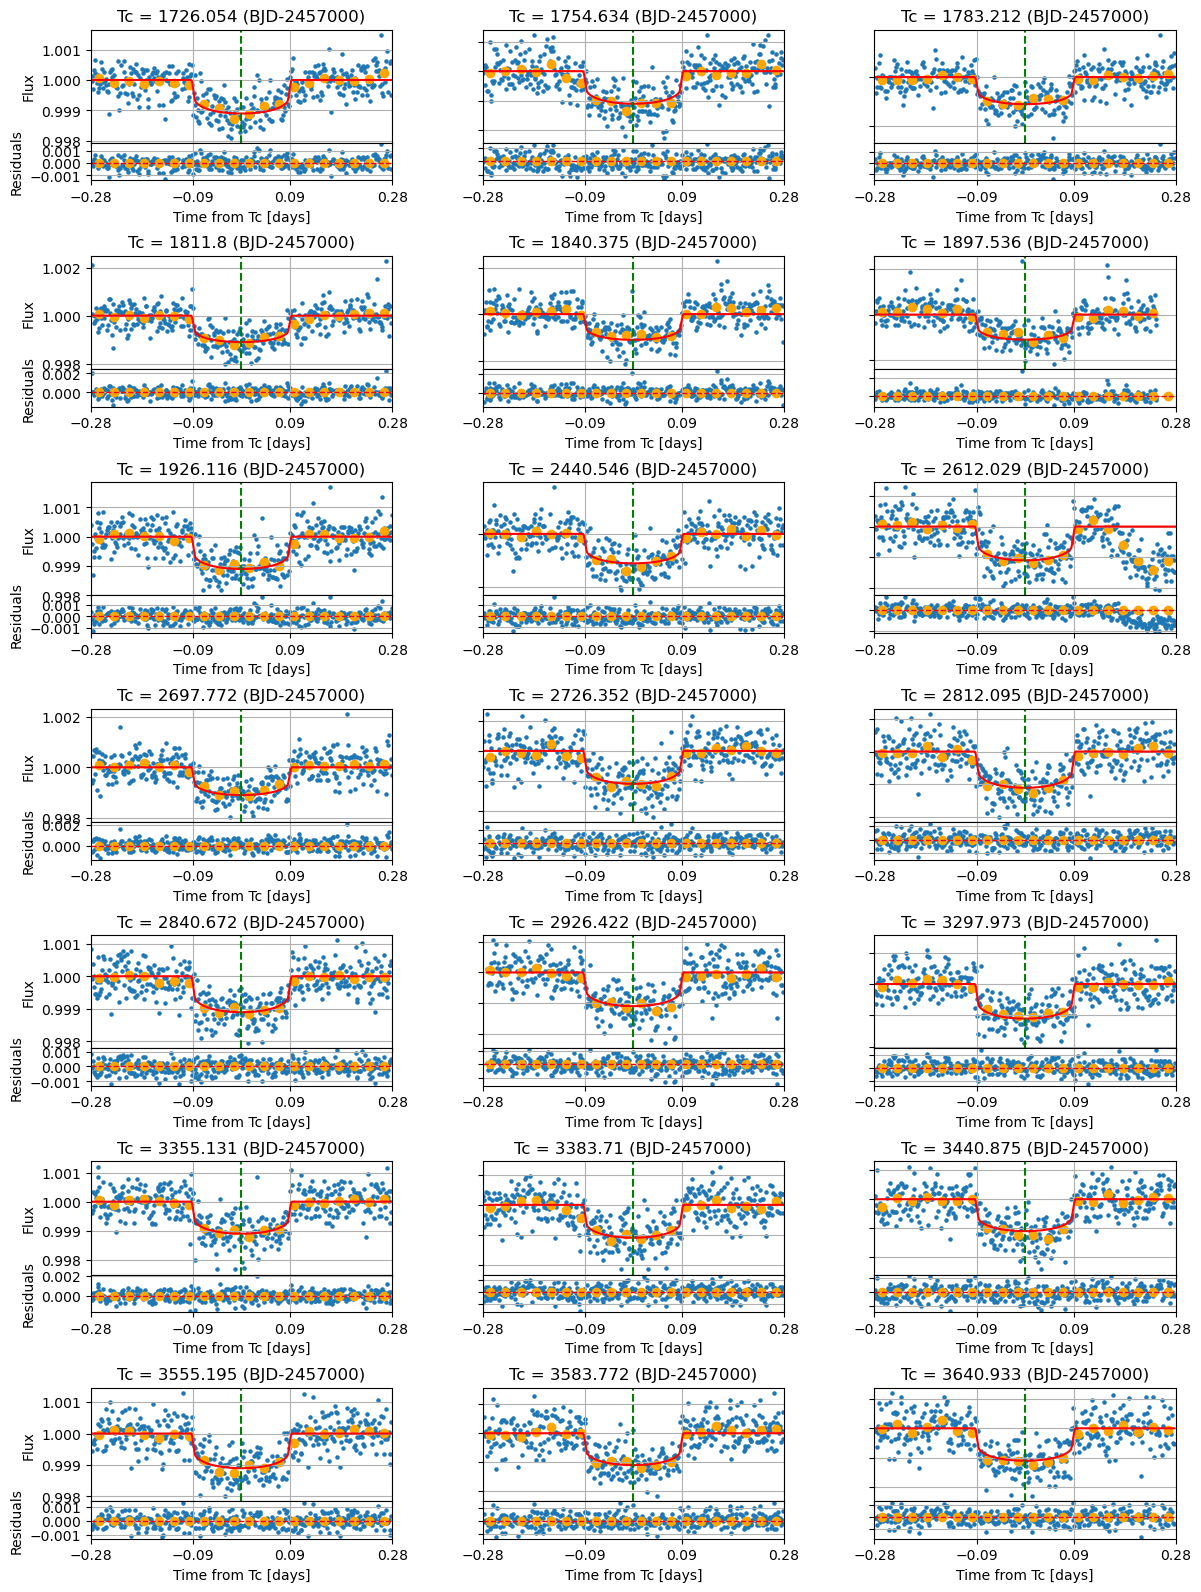

In [474]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

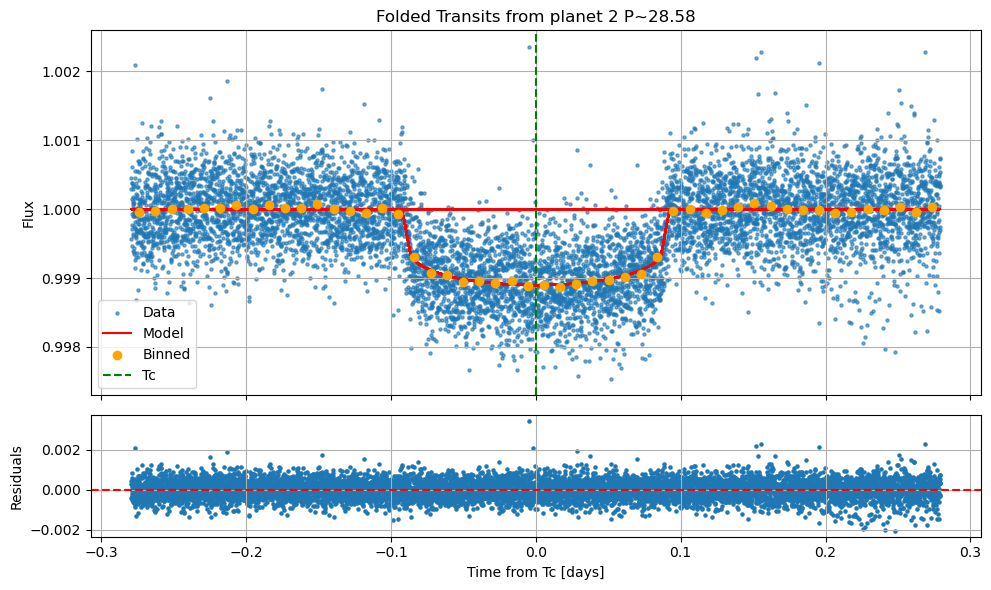

In [475]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

## Planet 3

In [476]:
### Planet params (from barros et al 2022)
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [477]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - ttv_hour
    end = tc_guess_3[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [478]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
tc_chi_parabola = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
ttv_p = np.zeros(len(tc_3))
errors = []
errors_p = []
err_tc_chi = []

In [479]:
tc_chi_3, ttv_3, tc_err3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [480]:
print(tc_chi_3)

[1743.55228223 1781.90306766 1820.26553968 1896.96100511 1973.66406648
 2433.91564963 2664.0248792  2702.35487445 2740.71641832 2817.41048391
 2932.4622609  3354.30299295 3392.66192071 3546.07279456 3584.42124356
 3622.76793615 3661.12602256]


In [481]:
### after inspection of single transits
values_to_remove_3 = [3469.35964969, 3584.43525759]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_3_cleaned = []
ttv_3_cleaned = []
tc_err_3_cleaned = []

for i in range(len(tc_chi_3)):
    if not any(math.isclose(tc_chi_3[i], val, abs_tol=tolerance) for val in values_to_remove_3):
        tc_chi_3_cleaned.append(tc_chi_3[i])
        ttv_3_cleaned.append(ttv_3[i])
        tc_err_3_cleaned.append(tc_err3[i])

# Overwrite the originals if needed
tc_chi_3 = tc_chi_3_cleaned
ttv_3 = ttv_3_cleaned
tc_err3 = tc_err_3_cleaned


print("Modified List (after removal):", tc_chi_3)


Modified List (after removal): [1743.5522822268827, 1781.9030676559116, 1820.2655396847936, 1896.96100510817, 1973.6640664787449, 2433.9156496340456, 2664.024879204517, 2702.3548744476616, 2740.7164183232103, 2817.4104839147385, 2932.462260903496, 3354.3029929461736, 3392.6619207076765, 3546.072794556178, 3622.7679361489895, 3661.1260225588803]


In [482]:
# tc_err_3 = []
# for i in range(len(tc_err3)):
#     sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
#     tc_err_3.append(sig)

tc_err_3 = []
for i in range(len(tc_err3)):
    if len(tc_err3[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
        tc_err_3.append(sig)
    else:
        print(f"Unexpected format in tc_err3[{i}]: {tc_err3[i]}, {tc_chi_3[i]}")

print(tc_err_3)

[0.0022221617300416164, 0.0018402198191873242, 0.0018838830537067062, 0.0023977709870140885, 0.001655429345148974, 0.0017829931143552426, 0.002142785454686775, 0.002149170773536144, 0.001692183252817096, 0.0017442626492491092, 0.0014695709532060338, 0.0024552818193923145, 0.0018398572958309785, 0.0016510059078570938, 0.0017367689450111798, 0.0021672567258158573]


In [483]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi_3

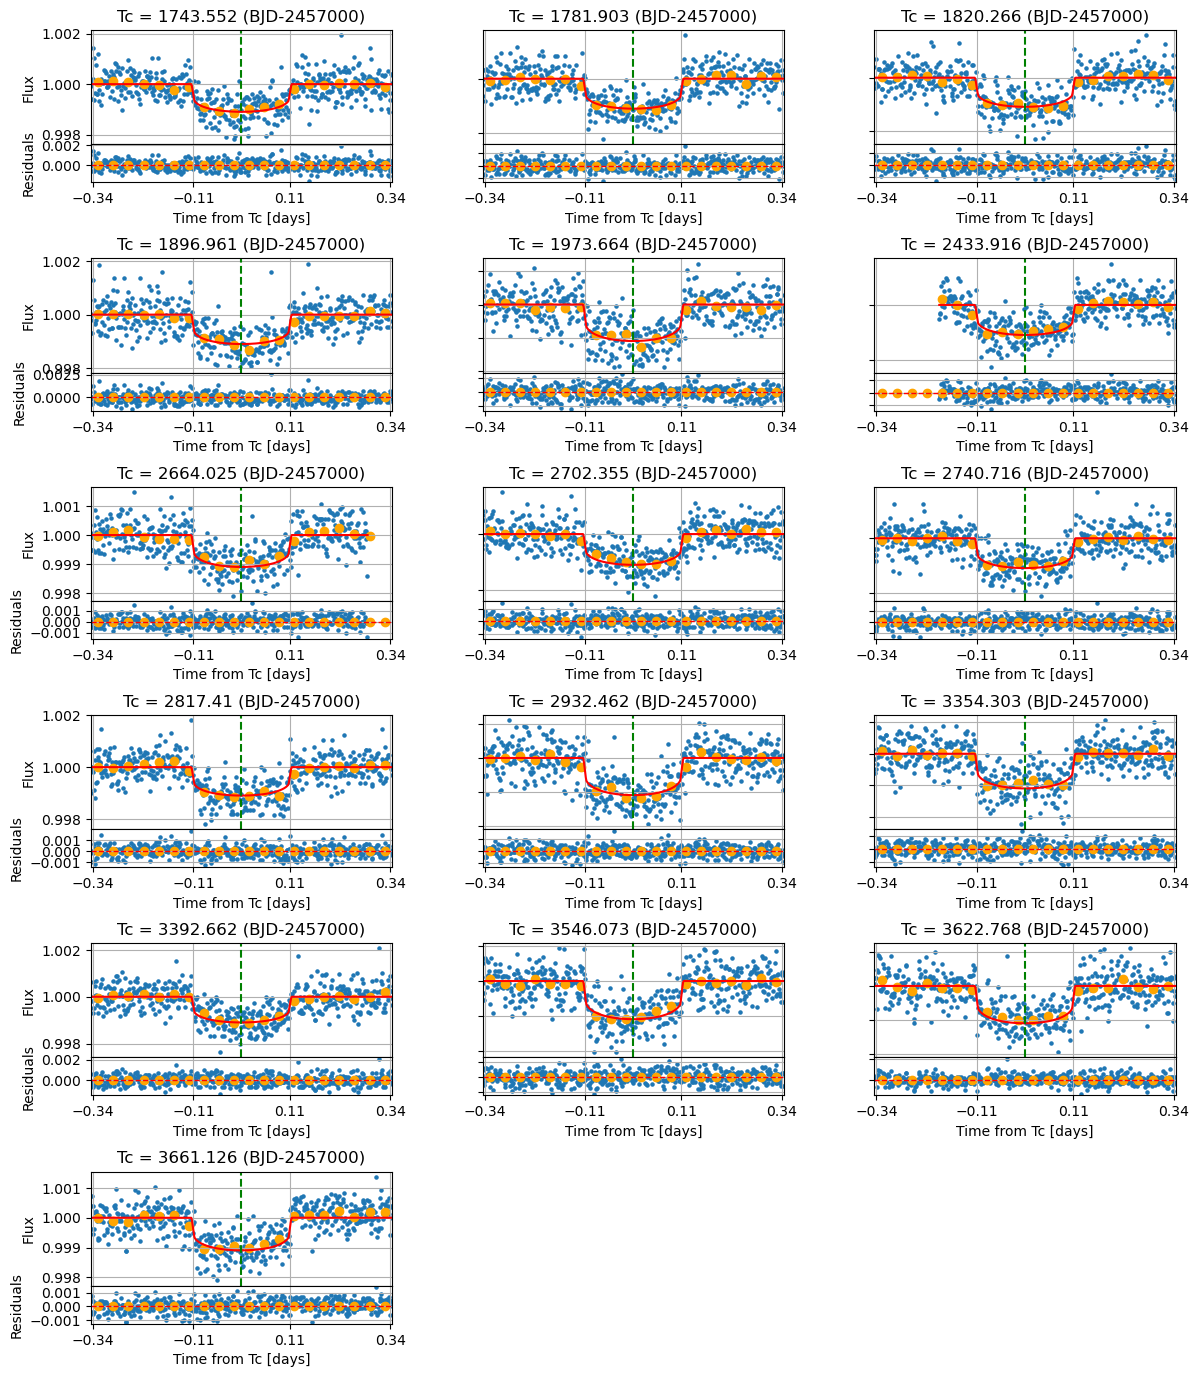

In [484]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

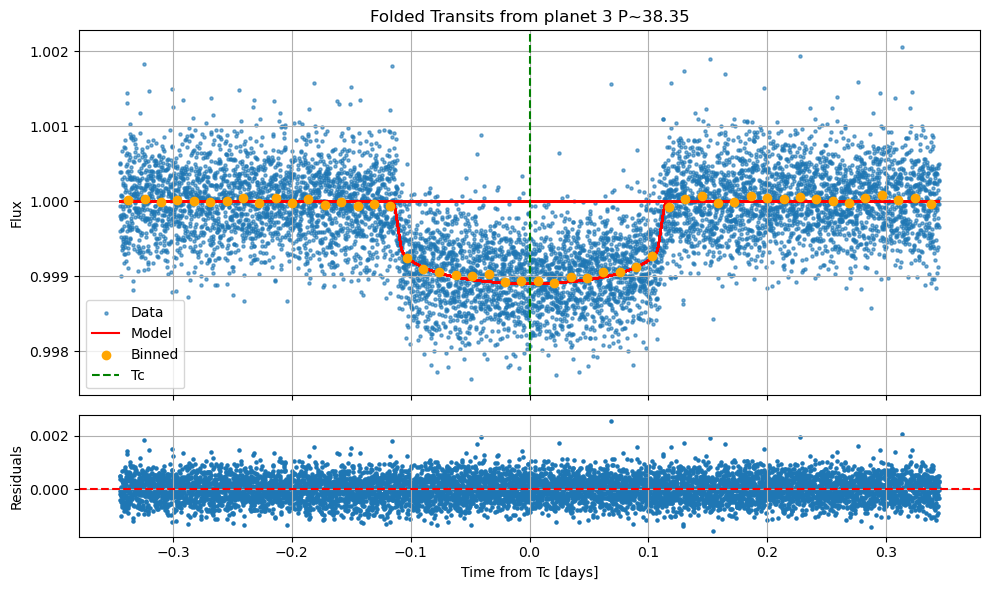

In [485]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 3 P~{round(planet_3_period.value, 3)}')

## Save data

In [486]:
print(len(transit_times_2))
print(len(transit_times_3))

21
16


In [487]:
print(planet_1_period.value)
print(planet_2_period.value)
print(planet_3_period.value)
print(planet_1_t0.value)
print(planet_2_t0.value)
print(planet_3_t0.value)
print(transit_times_2)
print(transit_times_3)
print(tc_err_1)
print(tc_err_2)
print(tc_err_3)
transit_times_2 = np.array(transit_times_2)
transit_times_3 = np.array(transit_times_3)

# Calculate the indices of transits for each planet
indices_1 = np.round((transit_times_1 - planet_1_t0.value) / planet_1_period.value).astype(int)
indices_2 = np.round((transit_times_2 - planet_2_t0.value) / planet_2_period.value).astype(int)
indices_3 = np.round((transit_times_3 - planet_3_t0.value) / planet_3_period.value).astype(int)

print("Indices of transits for planet 1:", indices_1)
print("Indices of transits for planet 2:", indices_2)
print("Indices of transits for planet 3:", indices_3)


8.880088008800879
28.579657965796578
38.35013501350135
1715.385773734107
1726.070773734107
1743.600773734107
[1726.0543073746499, 1754.634043965897, 1783.2115328271677, 1811.799709252357, 1840.375325305024, 1897.535580205685, 1926.1164468441034, 2440.5464000264496, 2612.028543417274, 2697.771827053584, 2726.351987285226, 2812.0954555257877, 2840.6723275065156, 2926.4215475832184, 3297.9726631034496, 3355.130554203686, 3383.7103874786258, 3440.8754011789956, 3555.19503141751, 3583.7721295971896, 3640.9330744268664]
[1743.5522822268827, 1781.9030676559116, 1820.2655396847936, 1896.96100510817, 1973.6640664787449, 2433.9156496340456, 2664.024879204517, 2702.3548744476616, 2740.7164183232103, 2817.4104839147385, 2932.462260903496, 3354.3029929461736, 3392.6619207076765, 3546.072794556178, 3622.7679361489895, 3661.1260225588803]
[0.0011728117497681952, 0.0017197523879606462, 0.001633090693207188, 0.001132055299083004, 0.0014934548214378311, 0.0023767717158326824, 0.0022513333798010442, 0.00

In [488]:
### saving data for planets 2 and 3 (resonant pair)

planet_number = []
# for i in range(len(transit_times_1)):
#     planet_number.append(1)
for i in range(len(transit_times_2)):
    planet_number.append(2)
for i in range(len(transit_times_3)):
    planet_number.append(3)

all_transit_num = [] 
# for i in range(len(indices_1)):
#     all_transit_num.append(indices_1[i])
for i in range(len(indices_2)):
    all_transit_num.append(indices_2[i])
for i in range(len(indices_3)):
    all_transit_num.append(indices_3[i])

all_obs_tc = []
# for i in range(len(transit_times_1)):
#     all_obs_tc.append(transit_times_1[i])
for i in range(len(transit_times_2)):
    all_obs_tc.append(transit_times_2[i])
for i in range(len(transit_times_3)):
    all_obs_tc.append(transit_times_3[i])

all_obs_tc_err = []
# for i in range(len(tc_err_1)):
#     all_obs_tc_err.append(tc_err_1[i])
for i in range(len(tc_err_2)):
    all_obs_tc_err.append(tc_err_2[i])
for i in range(len(tc_err_3)):
    all_obs_tc_err.append(tc_err_3[i])



In [489]:
output_file = "toi_1339_transit_data_120s.txt"
### save
data_to_save = np.column_stack((planet_number, all_transit_num, all_obs_tc, all_obs_tc_err))

### Define header
header = "Planet_num Index Tc Tc_err"

### Save to file
np.savetxt(output_file, data_to_save, fmt='%d %d %.8f %.8f', header=header, comments='')

print(f"Results saved to {output_file}")

Results saved to toi_1339_transit_data_120s.txt


# O-C

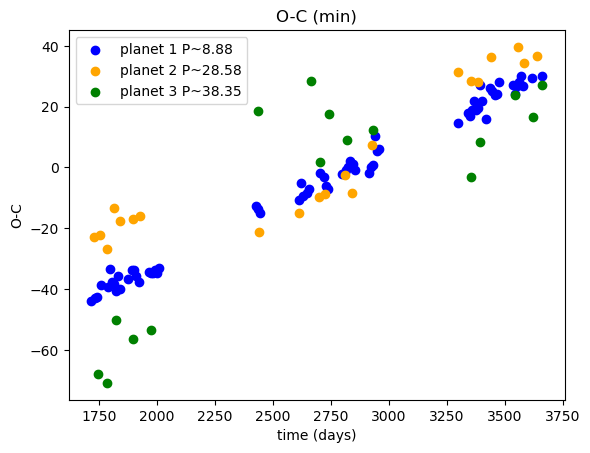

In [490]:
# TTV
ttv_1 = np.array(ttv_1)
ttv_2 = np.array(ttv_2)
ttv_3 = np.array(ttv_3)


plt.scatter(tc_chi_1, ttv_1*(24*60),c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

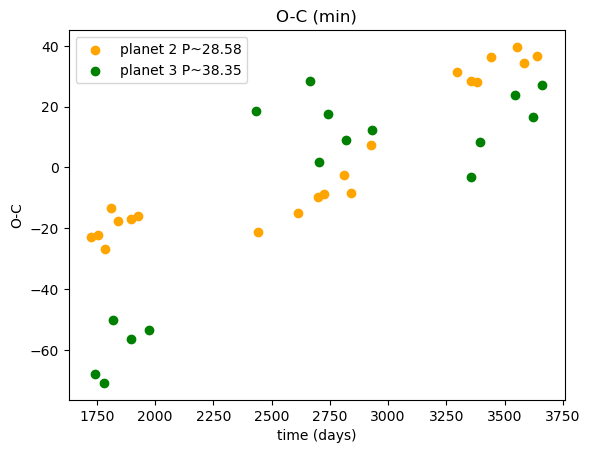

In [491]:
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

[-4.88795334e-03  6.49287208e-02 -6.17427339e+00 -9.70879344e-05]
[ 7.17159130e-03  6.41895037e-02 -4.05424662e+00 -2.43110230e-04]


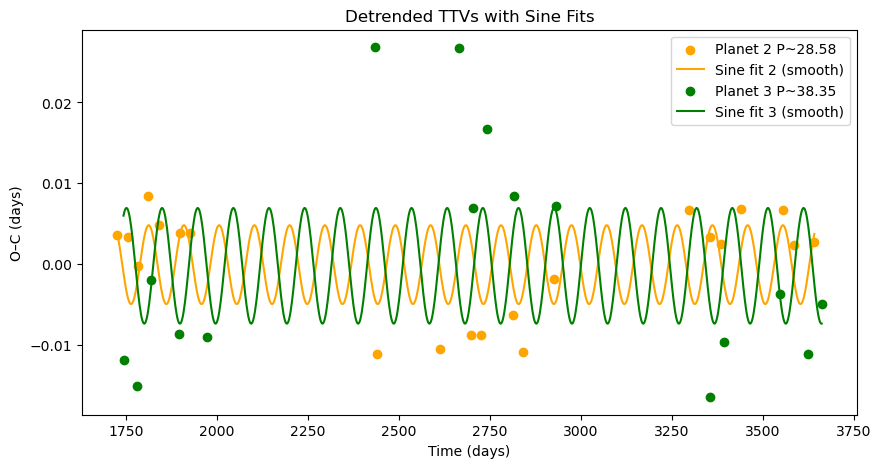

In [492]:
# Fit functions
def linear(x, a, b):
    return a * x + b

def sine(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset
# Fit and subtract for planet 2
popt_lin_2, _ = curve_fit(linear, tc_chi_2, ttv_2)
ttv_2_detrended = ttv_2 - linear(np.array(tc_chi_2), *popt_lin_2)

# Fit and subtract for planet 3
popt_lin_3, _ = curve_fit(linear, tc_chi_3, ttv_3)
ttv_3_detrended = ttv_3 - linear(np.array(tc_chi_3), *popt_lin_3)

# Initial guess: amplitude, frequency (rad/day), phase, offset
guess_2 = [0.01, 2 * np.pi / 100, 0, 0]
popt_sin_2, _ = curve_fit(sine, tc_chi_2, ttv_2_detrended, p0=guess_2)
print(popt_sin_2)

guess_3 = [0.03, 2 * np.pi / 100, 0, 0]
popt_sin_3, _ = curve_fit(sine, tc_chi_3, ttv_3_detrended, p0=guess_3)
print(popt_sin_3)

# Dense time arrays for smooth plots
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Detrended fits: only plot sine on linear-subtracted times
sine_fit_2 = sine(dense_time_2, *popt_sin_2)
sine_fit_3 = sine(dense_time_3, *popt_sin_3)

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended, color='orange', label=f'Planet 2 P~{round(planet_2_period.value, 3)}')
plt.plot(dense_time_2, sine_fit_2, 'orange', label='Sine fit 2 (smooth)')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended, color='green', label=f'Planet 3 P~{round(planet_3_period.value, 3)}')
plt.plot(dense_time_3, sine_fit_3, 'g', label='Sine fit 3 (smooth)')

plt.title('Detrended TTVs with Sine Fits')
plt.xlabel('Time (days)')
plt.ylabel('O–C (days)')
plt.legend()
plt.show()

[ 2.27057632e-05 -5.99502790e-02 -4.06870039e-03  1.68884979e-02
 -1.06994254e+00]
[ 3.12840781e-05 -8.94346482e-02 -9.40366547e-03  1.69368683e-02
 -4.17038718e+00]


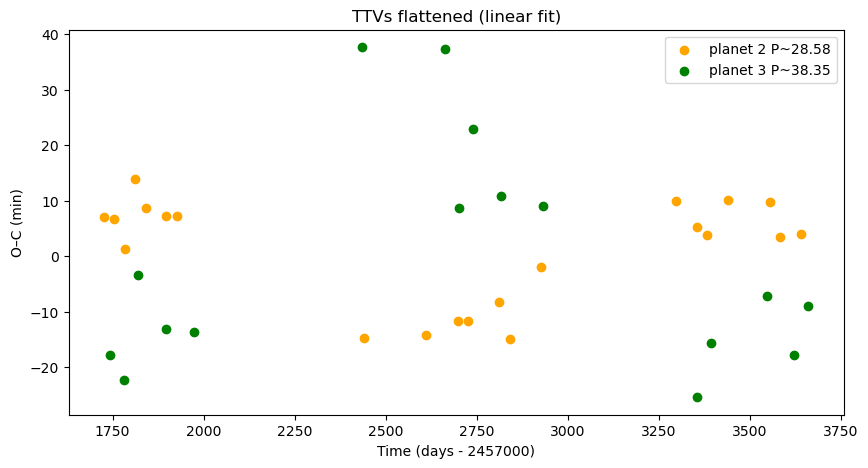

In [493]:
def linear_sine(t, a, b, A, omega, phase):
    return a * t + b + A * np.sin(omega * t + phase)

# Convert TTVs to minutes
ttv_2_min = np.array(ttv_2)
ttv_3_min = np.array(ttv_3) 

# Initial guesses: [slope, intercept, amplitude, omega, phase]
guess_2 = [28, 0, 0.01, 0.5*3.26255812e-02, 0]
guess_3 = [38, 0, 0.05, 0.5*3.05795071e-02, 0]

# Fit for planet 2
popt_2, _ = curve_fit(linear_sine, tc_chi_2, ttv_2_min, p0=guess_2)

# Fit for planet 3
popt_3, _ = curve_fit(linear_sine, tc_chi_3, ttv_3_min, p0=guess_3)

print(popt_2)
print(popt_3)

def linear_only(t, a, b):
    return a * t + b

ttv_2_detrended = ttv_2_min - linear_only(np.array(tc_chi_2), *popt_2[:2])
ttv_3_detrended = ttv_3_min - linear_only(np.array(tc_chi_3), *popt_3[:2])

# Dense time arrays for smooth curves
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Full model predictions
fit_2_full = linear_sine(dense_time_2, *popt_2)
fit_3_full = linear_sine(dense_time_3, *popt_3)

# Sine-only on detrended
fit_2_sine = fit_2_full - linear_only(dense_time_2, *popt_2[:2])
fit_3_sine = fit_3_full - linear_only(dense_time_3, *popt_3[:2])

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended*24*60, color='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
# plt.plot(dense_time_2, fit_2_sine, 'orange', label='Sine fit 2')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended*24*60, color='green', label=f'planet 3 P~{round(planet_3_period.value,3)}')
# plt.plot(dense_time_3, fit_3_sine, 'g', label='Sine fit 3')

plt.title('TTVs flattened (linear fit)')
plt.xlabel(f'Time (days - {TESS_offset})')
plt.ylabel('O–C (min)')
plt.legend()
plt.show()

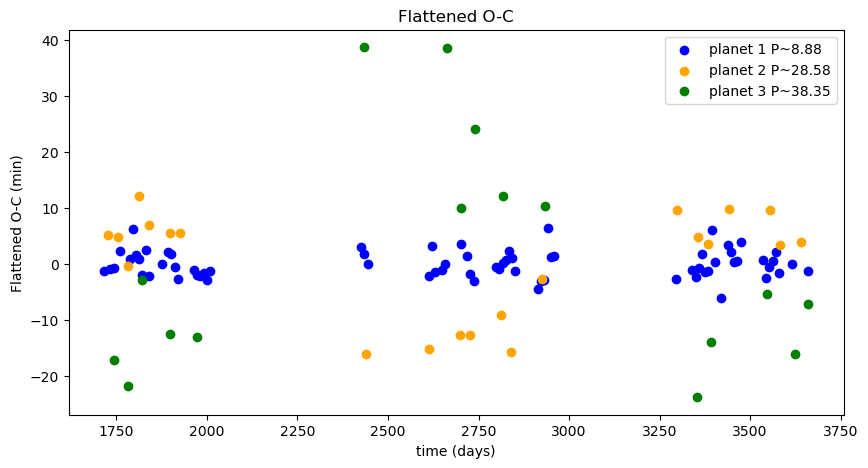

In [494]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

coeffs_3 = np.polyfit(tc_chi_3, ttv_3*(24*60), 1)
linear_fit_3 = np.polyval(coeffs_3, tc_chi_3)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2
ttv_3_detrended = ttv_3*(24*60) - linear_fit_3


plt.figure(figsize=(10, 5))
# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended,c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended,c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3_detrended,c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

## Multi-harmonic fit

In [495]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [496]:
j = 4 # 4:3 MMR
p_2 = planet_2_period.value
p_3 = planet_3_period.value
tc_2 = planet_2_t0.value
tc_3 = planet_3_t0.value


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006401171579743181
TTV period: 1497.7779667265215 days


In [497]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [498]:
### assuming circular orbit
Z=0


In [499]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [500]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [501]:
from scipy.optimize import least_squares
indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)
indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)

### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 1.72604693e+03  2.85803134e+01  7.94747442e-03  1.74357063e+03
  3.83512753e+01 -1.72115124e-02  1.65859122e+03  1.29280706e+03]


In [502]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [503]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04692706 ± 0.00080479
   P_b = 28.58031341 ± 0.00001889
  A_bc = 0.00794747 ± 0.00056329
  t_c0 = 1743.57062813 ± 0.00137333
   P_c = 38.35127526 ± 0.00004970
  A_cb = -0.01721151 ± 0.00079530
  P_cb = 1658.59122019 ± 54.22231176
 t_cb0 = 1292.80706015 ± 54.73909013


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_1351/2680994792.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


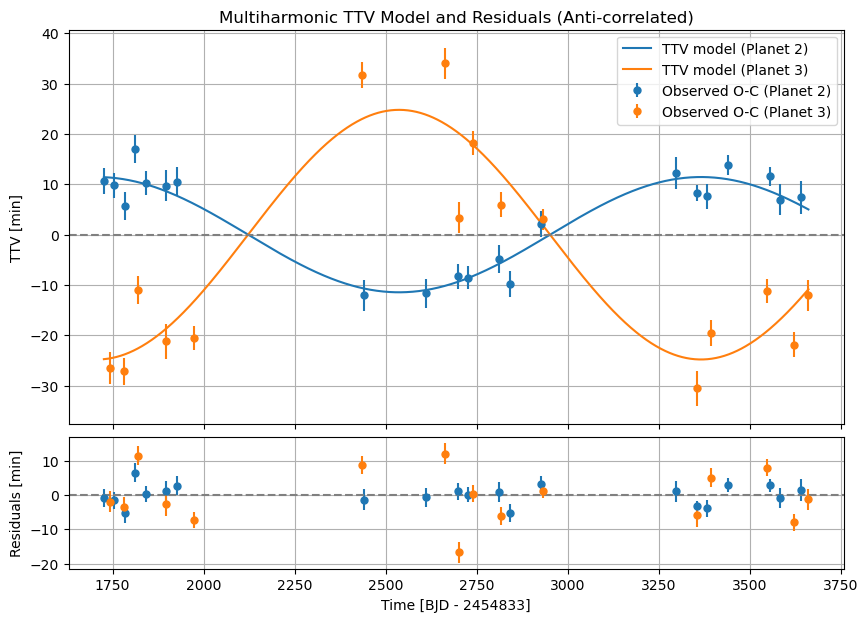

In [504]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) * 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) * 1440  # <- NEGATE here

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) * 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) * 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) * 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) * 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [min]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [min]")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [505]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_23: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_32: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 1658.59122 ± 54.222312 days
A_23: 11.443679999999999 ± 0.81072 min
A_32: -24.785280000000004 ± 1.1448 min


In [506]:
import pickle

# Bundle all relevant data into a dictionary
ttv_data = {
    "tc_lin_obs_2": t_lin_obs_b,
    "tc_lin_obs_3": t_lin_obs_c,
    "omc_2": oc_b,
    "omc_3": oc_c,
    "ttv_model_2": ttv_model_b,
    "ttv_model_3": ttv_model_c,
    "residuals_2": residuals_b,
    "residuals_3": residuals_c,
    "tc_err_2": np.array(tc_err_2),
    "tc_err_3": np.array(tc_err_3),
    "indices_2": np.array(indices_2),
    "indices_3": np.array(indices_3)
}

# Save to a file
with open("1339_data.pkl", "wb") as f:
    pickle.dump(ttv_data, f)


## Lithwick formalism

In [509]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

def z_free_k(ek, pomega_k):
    z = ek*np.cos(pomega_k) + 1j*ek*np.sin(pomega_k)
    return z

def Z_free_(z_free_1, z_free_2, f, g):
    Z_free = f*z_free_1 + g*z_free_2
    return Z_free

In [510]:
### for 4:3 MMR
f = -2.840
g = 3.283
j=4
### from orell-miquel et al 2022
e2 = 0.034
e3 = 0.031
omega2 = np.deg2rad(-90)
omega3 = np.deg2rad(15)

In [513]:
z_free_2 = z_free_k(e2, omega2)
print(z_free_2)
z_free_3 = z_free_k(e3, omega3)
print(z_free_3)
Z_free = Z_free_(z_free_2, z_free_3, f, g)
print(Z_free)

(2.0818995585505005e-18-0.034j)
(0.029943700614961117+0.008023390398178143j)
(0.09830516911891735+0.12290079067721885j)
